# Machine Learning Model Training

In this notebook, we will train different machine learning models for Insider Threat Detection.

The objective is to classify employees into:

- Normal Employee (0)
- Insider Threat (1)

We will compare different algorithms and select the best performing model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
DATA_PATH = Path("../DATA/processed")

X_train = pd.read_csv(DATA_PATH / "X_train.csv")
X_test = pd.read_csv(DATA_PATH / "X_test.csv")

y_train = pd.read_csv(DATA_PATH / "y_train.csv").squeeze()
y_test = pd.read_csv(DATA_PATH / "y_test.csv").squeeze()

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (6392, 47)
Testing Features : (800, 47)
Training Labels  : (6392,)
Testing Labels   : (800,)


In [3]:
print("X_train Shape:")
print(X_train.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

X_train Shape:
(6392, 47)

Training Class Distribution:
label
0    3196
1    3196
Name: count, dtype: int64


In [4]:
# Train Logistic Regression Model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [5]:
# Train Decision Tree Model
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


# Train Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Advantages:

- Reduces overfitting
- Handles non-linear relationships
- Provides feature importance
- Performs well on cybersecurity datasets

In [6]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(
    X_train,
    y_train
)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [7]:
# Make Predictions
logistic_pred = logistic_model.predict(X_test)

decision_tree_pred = decision_tree.predict(X_test)

random_forest_pred = random_forest.predict(X_test)

In [8]:
# Import Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [9]:
# Evaluate All Models
models = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": decision_tree_pred,
    "Random Forest": random_forest_pred
}

results = []

for name, prediction in models.items():

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(
        y_test,
        prediction,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        zero_division=0
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.98500,0.0,0.0,0.0
1,Decision Tree,0.99750,0.0,0.0,0.0
2,Random Forest,0.99875,0.0,0.0,0.0


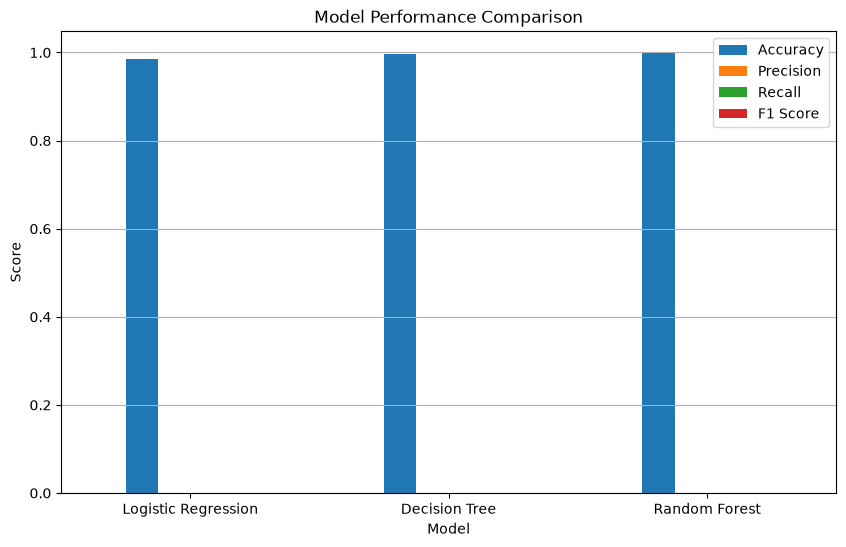

In [10]:
# Visualize Model Performance
results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

# Save the Best Model

The best-performing model will be saved for evaluation and deployment in the next notebooks.

In [11]:
import joblib
from pathlib import Path

MODEL_PATH = Path("../MODELS")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

joblib.dump(random_forest, MODEL_PATH / "random_forest_model.pkl")

print("✅ Random Forest model saved successfully!")

✅ Random Forest model saved successfully!


In [12]:
print("Training Class Distribution")
print(y_train.value_counts())

print("\nTesting Class Distribution")
print(y_test.value_counts())

Training Class Distribution
label
0    3196
1    3196
Name: count, dtype: int64

Testing Class Distribution
label
0    799
1      1
Name: count, dtype: int64


In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, random_forest_pred)

print(cm)

[[799   0]
 [  1   0]]


In [14]:
print(X_train.shape) 
print(y_train.value_counts())

(6392, 47)
label
0    3196
1    3196
Name: count, dtype: int64


In [ ]:
#save all models
import joblib
from pathlib import Path

# Create MODELS folder
MODEL_PATH = Path("../MODELS")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Save Logistic Regression
joblib.dump(
    logistic_model,
    MODEL_PATH / "logistic_regression.pkl"
)

# Save Decision Tree
joblib.dump(
    decision_tree,
    MODEL_PATH / "decision_tree.pkl"
)

# Save Random Forest
joblib.dump(
    random_forest,
    MODEL_PATH / "random_forest_model.pkl"
)

print("All models saved successfully.")

All models saved successfully.


In [ ]:
#verify if the MODELS folder exists and list the files inside it
print("MODEL Folder Exists:", MODEL_PATH.exists())

print("\nFiles inside MODELS folder:")

for file in MODEL_PATH.iterdir():
    print(file.name)

MODEL Folder Exists: True

Files inside MODELS folder:
.gitkeep
decision_tree.pkl
logistic_regression.pkl
random_forest_model.pkl
